# Expected Improvement

This section describes one of the widely used methods for performing balanced exploration and exploitation. Specifically, expected improvement (EI) is used as the acquisition function. The auxiliary optimization problem is written as:

$$
    \max_{\mathbf{x} \in \Omega} \text{ EI}(\mathbf{x}),
$$

where EI is written as

$$
    \text{EI}(\mathbf{x}) = \begin{cases}
        [f^* - \mu(\mathbf{x})] \cdot \Phi(\mathrm{Z}) + \sigma(\mathbf{x}) \cdot \phi(\textrm{Z}) & \text{if } \sigma(\mathbf{x}) > 0 \\
        0 & \text{if } \sigma(\mathbf{x}) = 0
    \end{cases}
$$

where $\Phi$ and $\phi$ are cumulative distribution and probability density function of the standard normal distribution, respectively. The $f^*$ is the current best value, and $\mu(\mathbf{x})$ and $\sigma(\mathbf{x})$ are model prediction and uncertainty in prediction (standard deviation) from surrogate model, respectively. The $\textrm{Z}$ is a standard normal variable that is computed as

$$
    \textrm{Z} = \frac{f^* - \mu(\mathbf{x})}{\sigma(\mathbf{x})}
$$

Note that $\hat{f}$ follows a normal distribution since it is modeled using a GP. The EI is a measure of the expected improvement of surrogate model at $x$ over the best observed value. The first term in EI represents exploitation and the second term represents exploration. Note that the acquisition function optimization is a maximization problem.

Below code imports required packages and defines modified branin function:

In [1]:
import numpy as np
import torch
from pyDOE3 import lhs
import matplotlib.pyplot as plt
from scipy.stats import norm as normal
from scimlstudio.models import SingleOutputGP
from scimlstudio.utils import Standardize, Normalize
from gpytorch.mlls import ExactMarginalLogLikelihood

from pymoo.core.problem import Problem
from pymoo.algorithms.soo.nonconvex.de import DE
from pymoo.optimize import minimize
from pymoo.config import Config
Config.warnings['not_compiled'] = False

# Defining the device and data types
args = {
    "device": torch.device('cuda' if torch.cuda.is_available() else 'cpu'),
    "dtype": torch.float64
}

def modified_branin(x: np.ndarray) -> np.ndarray:
    """
        Function for computing modified branin function value at given input points
    """

    x = np.atleast_2d(x)

    x1 = x[:,0]
    x2 = x[:,1]

    a = 1.
    b = 5.1 / (4.*np.pi**2)
    c = 5. / np.pi
    r = 6.
    s = 10.
    t = 1. / (8.*np.pi)

    y = a * (x2 - b*x1**2 + c*x1 - r)**2 + s*(1-t)*np.cos(x1) + s + 5*x1

    return np.expand_dims(y,-1)

lb = np.array([-5., 0.])
ub = np.array([10., 15.])

/home/pavan/miniconda3/envs/sm/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Below code block defines `pymoo` problem class and initializes differential evolution algorithm:

In [2]:
class ExpectedImprovement(Problem):

    def __init__(self, gp, lb: np.ndarray, ub: np.ndarray, fbest: float):
        """
            Class for defining auxiliary optimization problem that uses
            expected improvment as the acquisition function
        """

        # initialize parent class
        super().__init__(n_var=lb.shape[0], n_obj=1, n_constr=0, xl=lb, xu=ub)

        # store variables
        self.gp = gp
        self.fbest = fbest

    def _evaluate(self, x, out, *args, **kwargs):

        # convert to torch tensor
        x = torch.from_numpy(x).to(self.gp.x_train)

        # get mean prediction
        y_mean, y_var = self.gp.predict(x)

        # numerator of Z
        numerator = self.fbest - y_mean.numpy(force=True)

        # denominator of Z
        denominator = y_var.numpy(force=True)**0.5

        # std variable
        z = numerator / denominator

        # compute ei
        ei = numerator * normal.cdf(z) + denominator * normal.pdf(z)

        out["F"] = - ei # negating since pymoo minimizes

# Optimization algorithm
algorithm = DE(pop_size=15*lb.shape[0], F=0.9, CR=0.8, seed=1)

## BO loop

Below code implements BO loop with EI-based acquisition function. Four initial samples are used with a maximum function evaluation budget of 12. This implies that there will be 8 iterations of the loop. The initial samples are generated using latin hypercube sampling. A Gaussian process model is used to approximate the modified Branin function since it provides both point-prediction and uncertainty in prediction.

In [5]:
# variables
num_init = 4
max_evals = 16
num_evals = 0

# initial training data
x_train = lhs(lb.shape[0], samples=num_init, criterion='cm', iterations=100, seed=1)
x_train = lb + (ub - lb) * x_train
y_train = modified_branin(x_train)

# increment evals
num_evals += num_init

idx_best = np.argmin(y_train)
fbest = [y_train[idx_best]]
xbest = [x_train[idx_best]]

print("Current best before loop:")
print("x: {}".format(xbest[-1]))
print("f: {}".format(fbest[-1]))

print("\nLCB Loop:")

# loop
while num_evals < max_evals:

    print(f"\nIteration: {num_evals-num_init+1}")

    # GP
    gp = SingleOutputGP(
        x_train=torch.from_numpy(x_train).to(**args),
        y_train=torch.from_numpy(y_train).to(**args),
        output_transform=Standardize,
        input_transform=Normalize,
    )

    mll = ExactMarginalLogLikelihood(gp.likelihood, gp) # marginal log likelihood

    optimizer = torch.optim.Adam(gp.parameters(), lr=0.01) # optimizer

    # Training the model
    gp.fit(training_iterations=1000, mll=mll, optimizer=optimizer)

    # Find the minimum of surrogate model
    result = minimize(ExpectedImprovement(gp, lb, ub, fbest[-1]), algorithm, verbose=False)

    # Computing true function value at infill point
    y_infill = modified_branin(result.X)

    print("New point (based on EI):")
    print("x: {}".format(result.X))
    print("f: {}".format(y_infill.item()))

    # Appending the the new point to the current data set
    x_train = np.vstack(( x_train, result.X.reshape(1,-1) ))
    y_train = np.vstack((y_train, y_infill))

    # increment evals
    num_evals += 1

    # Find current best point
    idx_best = np.argmin(y_train)
    fbest.append(y_train[idx_best])
    xbest.append(x_train[idx_best])
    
    print("Current best:")
    print("x: {}".format(xbest[-1]))
    print("f: {}".format(fbest[-1]))

fbest = np.array(fbest)
xbest = np.array(xbest)

Current best before loop:
x: [-3.125  5.625]
f: [28.46841701]

LCB Loop:

Iteration: 1
New point (based on EI):
x: [-0.67709026  3.48786683]
f: 27.413485435068218
Current best:
x: [-0.67709026  3.48786683]
f: [27.41348544]

Iteration: 2
New point (based on EI):
x: [-5.          4.68422781]
f: 144.05206792764358
Current best:
x: [-0.67709026  3.48786683]
f: [27.41348544]

Iteration: 3
New point (based on EI):
x: [-2.87710984  5.64090805]
f: 22.436436695945062
Current best:
x: [-2.87710984  5.64090805]
f: [22.4364367]

Iteration: 4
New point (based on EI):
x: [-2.43177273  5.18378088]
f: 20.26543624215192
Current best:
x: [-2.43177273  5.18378088]
f: [20.26543624]

Iteration: 5
New point (based on EI):
x: [-2.57116263  7.00031621]
f: 4.6320343715009
Current best:
x: [-2.57116263  7.00031621]
f: [4.63203437]

Iteration: 6
New point (based on EI):
x: [-2.62835301  9.92424506]
f: -10.181128149553423
Current best:
x: [-2.62835301  9.92424506]
f: [-10.18112815]

Iteration: 7
New point (based 

Below code plots the evolution of optimum point with respect to number of iterations:

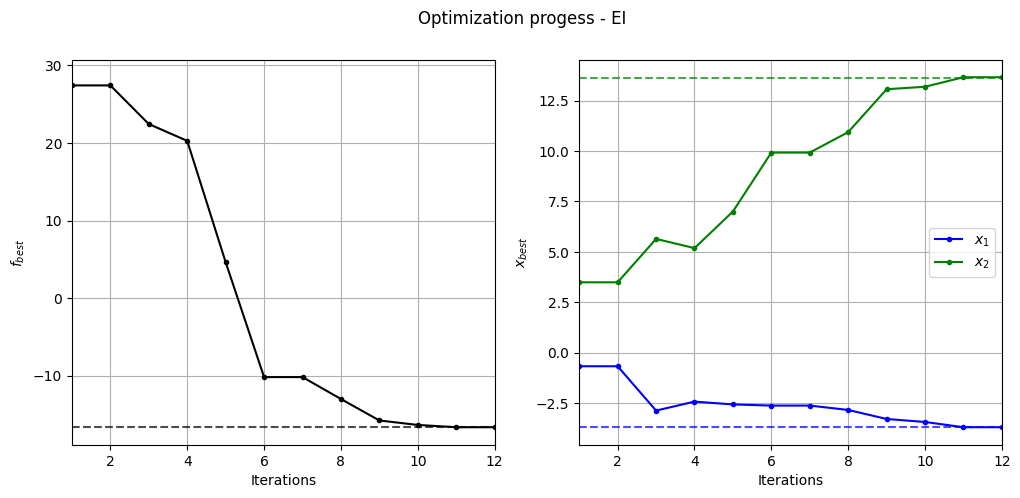

In [6]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

ax[0].plot(fbest, ".k-")
ax[0].set_xlabel("Iterations")
ax[0].set_ylabel("$f_{best}$")
ax[0].axhline(y=-16.64, c="k", linestyle="--", alpha=0.7)
ax[0].set_xlim(left=1, right=fbest.shape[0]-1)
ax[0].grid()

ax[1].plot(xbest[:,0], ".b-", label="$x_1$")
ax[1].plot(xbest[:,1], ".g-", label="$x_2$")
ax[1].axhline(y=-3.689, c="b", linestyle="--", alpha=0.7)
ax[1].axhline(y=13.630, c="g", linestyle="--", alpha=0.7)
ax[1].set_xlim(left=1, right=xbest.shape[0]-1)
ax[1].set_ylabel("$x_{best}$")
ax[1].set_xlabel("Iterations")
ax[1].legend()
ax[1].grid()

_ = plt.suptitle("Optimization progess - EI")

Below code plots the infill points added during the optimization process:

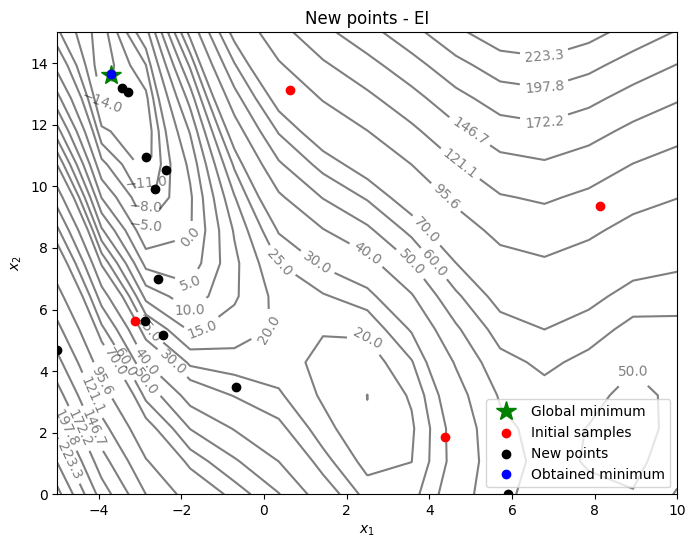

In [7]:
num_pts_per_dim = 15
x1 = np.linspace(lb[0], ub[0], num_pts_per_dim)
x2 = np.linspace(lb[1], ub[1], num_pts_per_dim)
X1, X2 = np.meshgrid(x1, x2)

x = np.hstack(( X1.reshape(-1,1), X2.reshape(-1,1) ))

Z = modified_branin(x).reshape(num_pts_per_dim, num_pts_per_dim)

# Level
levels = np.linspace(-17, -5, 5)
levels = np.concatenate((levels, np.linspace(0, 30, 7)))
levels = np.concatenate((levels, np.linspace(40, 60, 3)))
levels = np.concatenate((levels, np.linspace(70, 300, 10)))

fig, ax = plt.subplots(figsize=(8,6))

# Contours and global opt
CS=ax.contour(X1, X2, Z, levels=levels, colors='k', linestyles='solid', alpha=0.5, zorder=-10)
ax.clabel(CS, inline=1)
ax.plot(-3.689, 13.630, 'g*', markersize=15, label="Global minimum")

# Points
ax.scatter(x_train[0:num_init,0], x_train[0:num_init,1], c="red", label='Initial samples')
ax.scatter(x_train[num_init:,0], x_train[num_init:,1], c="black", label='New points')
ax.plot(xbest[-1][0], xbest[-1][1], 'bo', label="Obtained minimum")

# asthetics
ax.legend()
ax.set_xlabel("$x_1$")
ax.set_ylabel("$x_2$")
_ = ax.set_title("New points - EI")

From the above plots, it can be seen that EI finds the minimum of modified branin function while balancing exploration and exploitation. The EI adds some points in the unexplored regions before converging to global minimum.

> __*NOTE*__: Due to randomness in differential evolution and GP training, results may vary slightly between runs. So, it is recommended to run the code multiple times to see average behavior.